Figure Generation for Paper [Figure 3]: t-SNE Visualisation
Data loaded successfully.
Visualisation target: Company ID 75
Running t-SNE analysis... (may take a moment depending on data size)


C:\Users\miy\miniconda3\envs\diceml\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\miy\miniconda3\envs\diceml\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\miy\miniconda3\envs\diceml\lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(



[Figure 5] saved: figure5_tsne_visualization.png


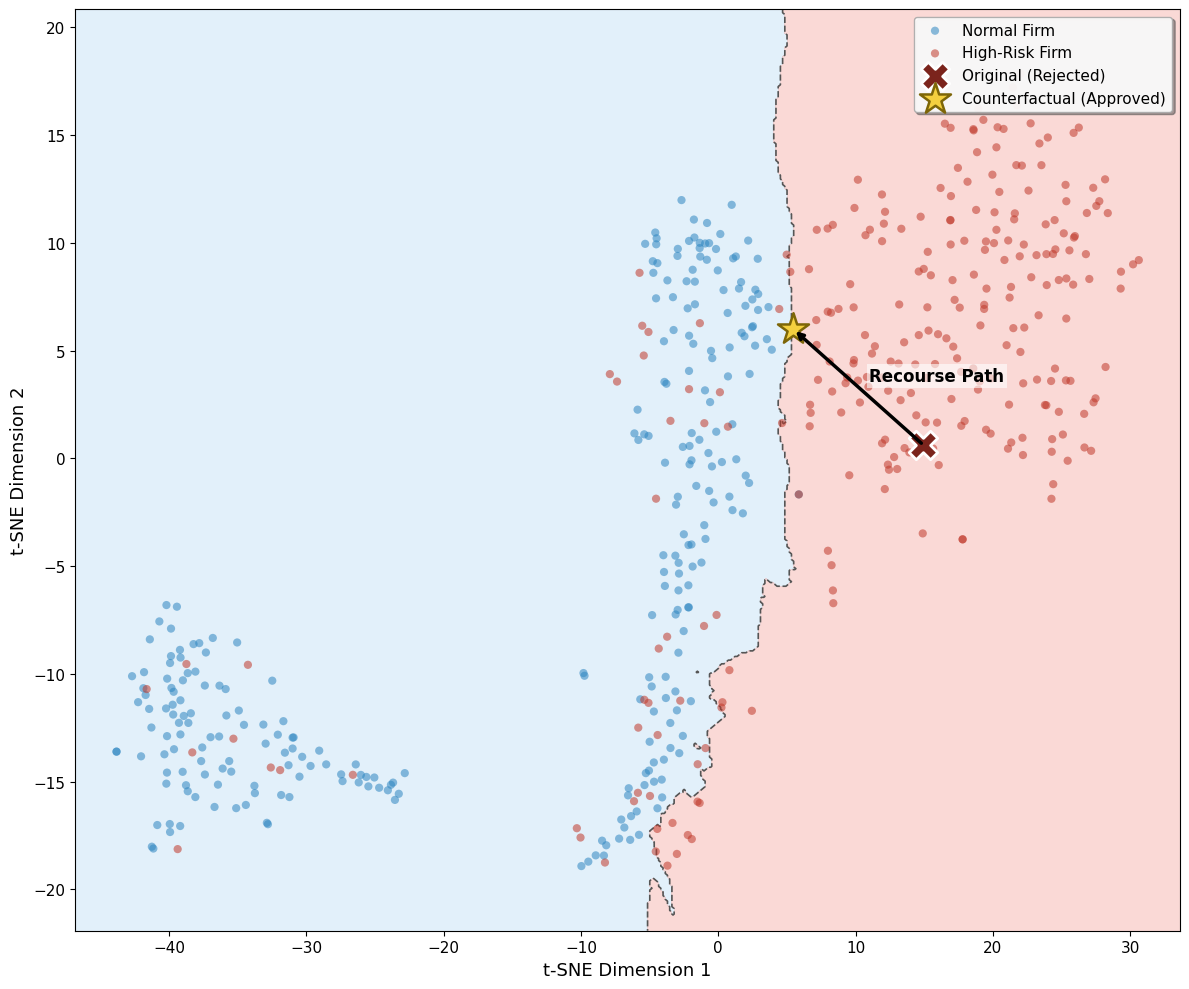

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import joblib
import os
import sys

print("=" * 80)
print("Figure Generation for Paper [Figure 3]: t-SNE Visualisation")
print("=" * 80)

# 1. Data Loading
# -------------------------------------------------------------------------
try:
    df_train = pd.read_csv('resampled_data_final.csv')       # Background distribution data
    features = joblib.load('selected_features_final.pkl')
    cf_results = pd.read_csv('cf_results_filtered.csv')       # Target firm and CF data
    print("Data loaded successfully.")
except Exception as e:
    print(f"[Error] {e}")
    print("Required files not found. Please run Step 2 and Step 4 first.")
    sys.exit(1)

# 2. Select Visualisation Target (Case ID: 75.0)
# -------------------------------------------------------------------------
target_id = 75.0
if target_id not in cf_results['ID'].values:
    target_id = cf_results['ID'].iloc[0]

target_row = cf_results[cf_results['ID'] == target_id].iloc[0]
print(f"Visualisation target: Company ID {int(target_id)}")

# 3. Data Preprocessing (Scaling + Concatenation)
# -------------------------------------------------------------------------
print("Running t-SNE analysis... (may take a moment depending on data size)")

X = df_train[features]
y = df_train['PERF_12M']

# Standardise features (required for t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Prepare original and CF vectors for the target firm
original_vec = np.array([target_row[f'Original_{f}'] for f in features]).reshape(1, -1)
cf_vec = np.array([target_row[f'CF_{f}'] for f in features]).reshape(1, -1)

orig_scaled = scaler.transform(original_vec)
cf_scaled = scaler.transform(cf_vec)

# t-SNE has no transform method, so append target points before fitting
X_combined = np.vstack([X_scaled, orig_scaled, cf_scaled])

# Labels: 0 = Solvent, 1 = Bankrupt, 2 = Target Original, 3 = Target CF
y_combined = np.hstack([y, [2], [3]])

# 4. Run t-SNE
# -------------------------------------------------------------------------
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    n_iter=1000,
    init='pca',
    learning_rate='auto'
)
X_tsne = tsne.fit_transform(X_combined)

# Separate coordinates
tsne_background = X_tsne[:-2]
tsne_orig = X_tsne[-2]
tsne_cf   = X_tsne[-1]

# 5. Build Decision Boundary via KNN on t-SNE coordinates
# -------------------------------------------------------------------------
# Fit KNN classifier on the 2-D t-SNE embedding (background points only)
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(tsne_background, y)

# Create a dense mesh grid that covers the full plot area
x_min, x_max = tsne_background[:, 0].min() - 3, tsne_background[:, 0].max() + 3
y_min, y_max = tsne_background[:, 1].min() - 3, tsne_background[:, 1].max() + 3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 6. Plot
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

# --- Decision boundary background (soft fill) ---
# approval zone = blue, rejection zone = red/pink
cmap_bg = ListedColormap(['#AED6F1', '#F1948A'])   # soft blue / soft red
ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg, levels=[-0.5, 0.5, 1.5])

# --- Crisp boundary line ---
ax.contour(xx, yy, Z, levels=[0.5], colors='#555555', linewidths=1.2, linestyles='--')

# --- Background scatter: solvent (blue) and bankrupt (red) firms ---
ax.scatter(tsne_background[y==0, 0], tsne_background[y==0, 1],
           c='#2E86C1', label='Normal Firm',
           alpha=0.55, s=35, edgecolors='none', zorder=3)
ax.scatter(tsne_background[y==1, 0], tsne_background[y==1, 1],
           c='#C0392B', label='High-Risk Firm',
           alpha=0.55, s=35, edgecolors='none', zorder=3)

# --- Original (Rejected) firm: bold dark-red X ---
ax.scatter(tsne_orig[0], tsne_orig[1],
           c='#7B241C', s=420, marker='X',
           label='Original (Rejected)',
           zorder=10, edgecolors='white', linewidths=2.0)

# --- Counterfactual (Approved): gold star ---
ax.scatter(tsne_cf[0], tsne_cf[1],
           c='#F4D03F', s=550, marker='*',
           label='Counterfactual (Approved)',
           zorder=10, edgecolors='#7D6608', linewidths=1.8)

# --- Arrow: recourse path ---
ax.annotate(
    '', 
    xy=(tsne_cf[0], tsne_cf[1]),
    xytext=(tsne_orig[0], tsne_orig[1]),
    arrowprops=dict(
        arrowstyle='->', color='black',
        lw=2.5,
        connectionstyle='arc3,rad=0.0'
    ),
    zorder=11
)

# --- "Recourse Path" label near arrow midpoint ---
mid_x = (tsne_orig[0] + tsne_cf[0]) / 2 + 0.8
mid_y = (tsne_orig[1] + tsne_cf[1]) / 2 + 0.3
ax.text(mid_x, mid_y, 'Recourse Path',
        fontsize=12, color='black', fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=2))

# --- Styling ---
ax.set_xlabel('t-SNE Dimension 1', fontsize=13)
ax.set_ylabel('t-SNE Dimension 2', fontsize=13)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.tick_params(labelsize=11)

# Legend (custom order: Normal, High-Risk, Original, CF)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels,
          loc='upper right', fontsize=11,
          frameon=True, framealpha=0.92, shadow=True,
          edgecolor='#AAAAAA')

plt.tight_layout()

# 7. Save
# -------------------------------------------------------------------------
out_path = 'figure5_tsne_visualization.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"\n[Figure 5] saved: {out_path}")